# Data Cleaning workflow
The purpose of this notebook is to showcase how we carried out data cleaning. What was removed and the output is the semi-processed data that will be used in the project.

Output data is stored in an untracked folder named data:
```bash
../data/
```

Running this script will automatically create the directory and store the data there.

In [1]:
# Load the required packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load the data
url = "https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv"
mtsamples = pd.read_csv(url).iloc[:, 1:]

In [3]:
mtsamples.shape

(4999, 5)

In [4]:
mtsamples.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [5]:
mtsamples.columns

Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords'],
      dtype='str')

In [3]:
# Drop columns without a transcript
mtsamples.dropna(subset=['transcription'], inplace=True)

- Cleaning the medical speciality column. The new target column is named: **medical_speciality_clean**

In [4]:
# Remove trailing whitespaces from the medical speciality column
mtsamples['medical_specialty_clean'] = mtsamples['medical_specialty'].str.strip()

In [8]:
top_specialities = mtsamples['medical_specialty'].value_counts()[lambda x: x >= 100]
print(top_specialities)

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
Name: count, dtype: int64


In [9]:
# Explore the medical speciality categories.
medical_specialty_10 = mtsamples['medical_specialty_clean'].value_counts()[:10]
medical_specialty_20 = mtsamples['medical_specialty_clean'].value_counts()[10:20]
medical_specialty_30 = mtsamples['medical_specialty_clean'].value_counts()[20:30]
medical_specialty_40 = mtsamples['medical_specialty_clean'].value_counts()[30:40]

In [10]:
medical_specialty_10

medical_specialty_clean
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64

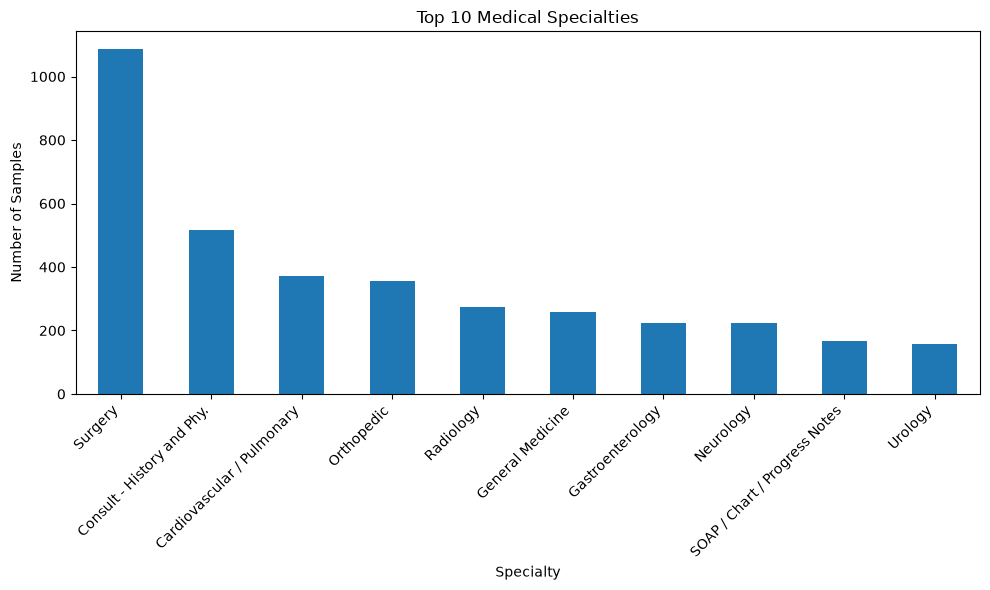

In [11]:
# Plot the medical specialties for visualisation
medical_specialty_10.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

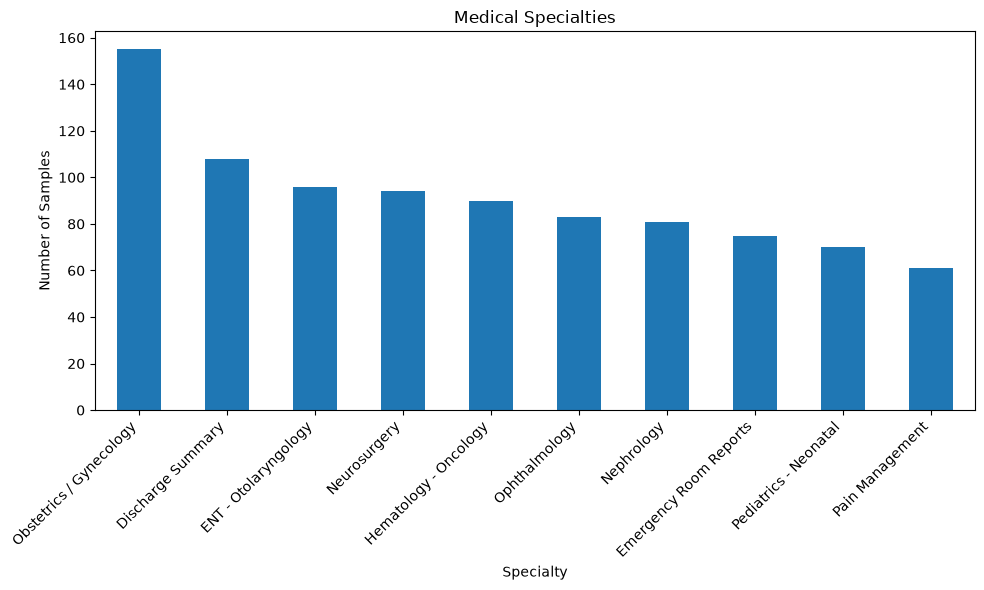

In [12]:
medical_specialty_20.plot(kind='bar', figsize=(10,6))
plt.title('Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

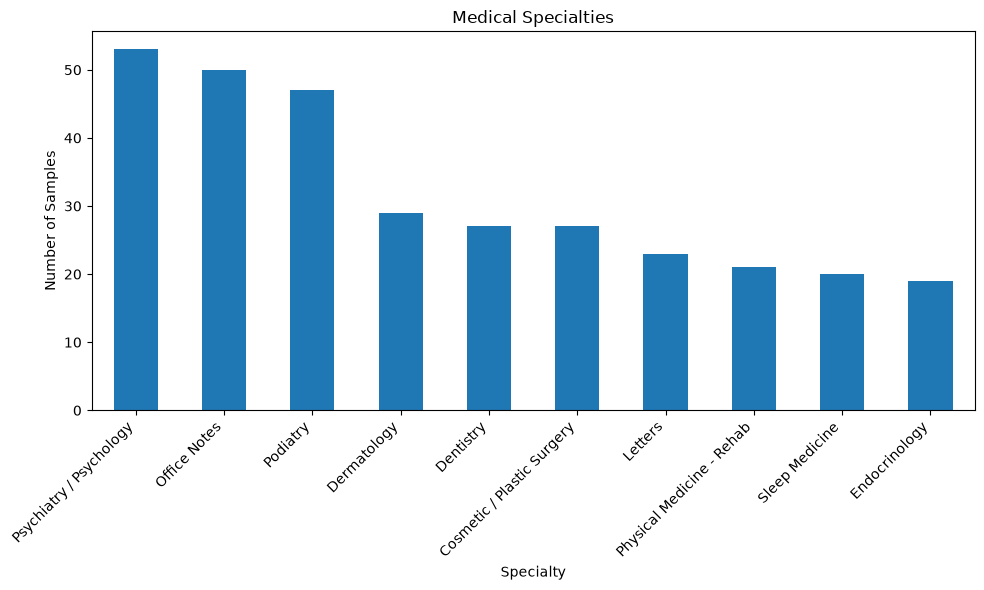

In [13]:
medical_specialty_30.plot(kind='bar', figsize=(10,6))
plt.title('Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')  # rotate labels for readability
plt.tight_layout()
plt.show()

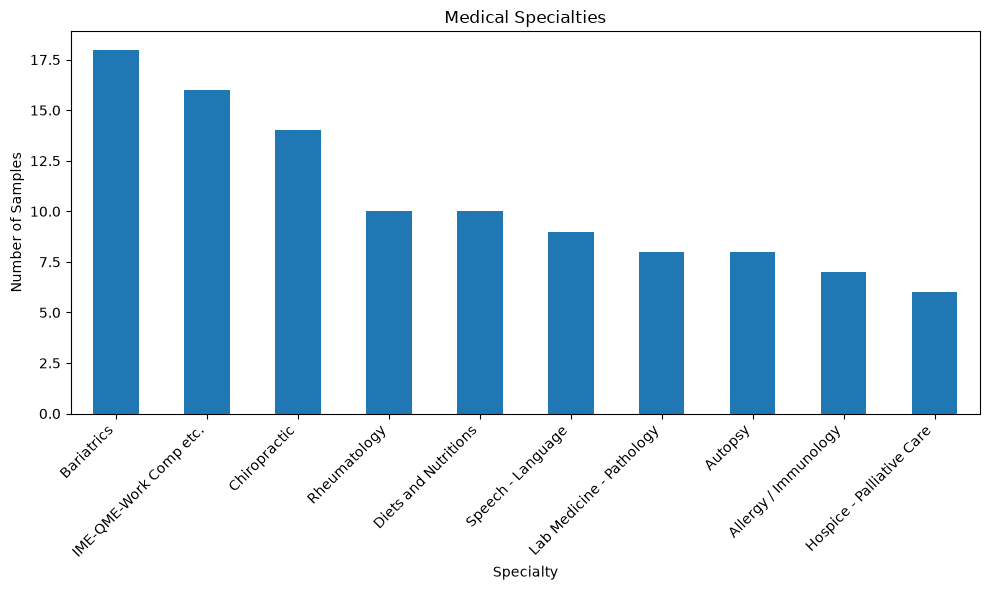

In [14]:
medical_specialty_40.plot(kind='bar', figsize=(10,6))
plt.title('Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We can then place all of the specialities in a single graph for fast comparison across all of them.

<Axes: ylabel='medical_specialty'>

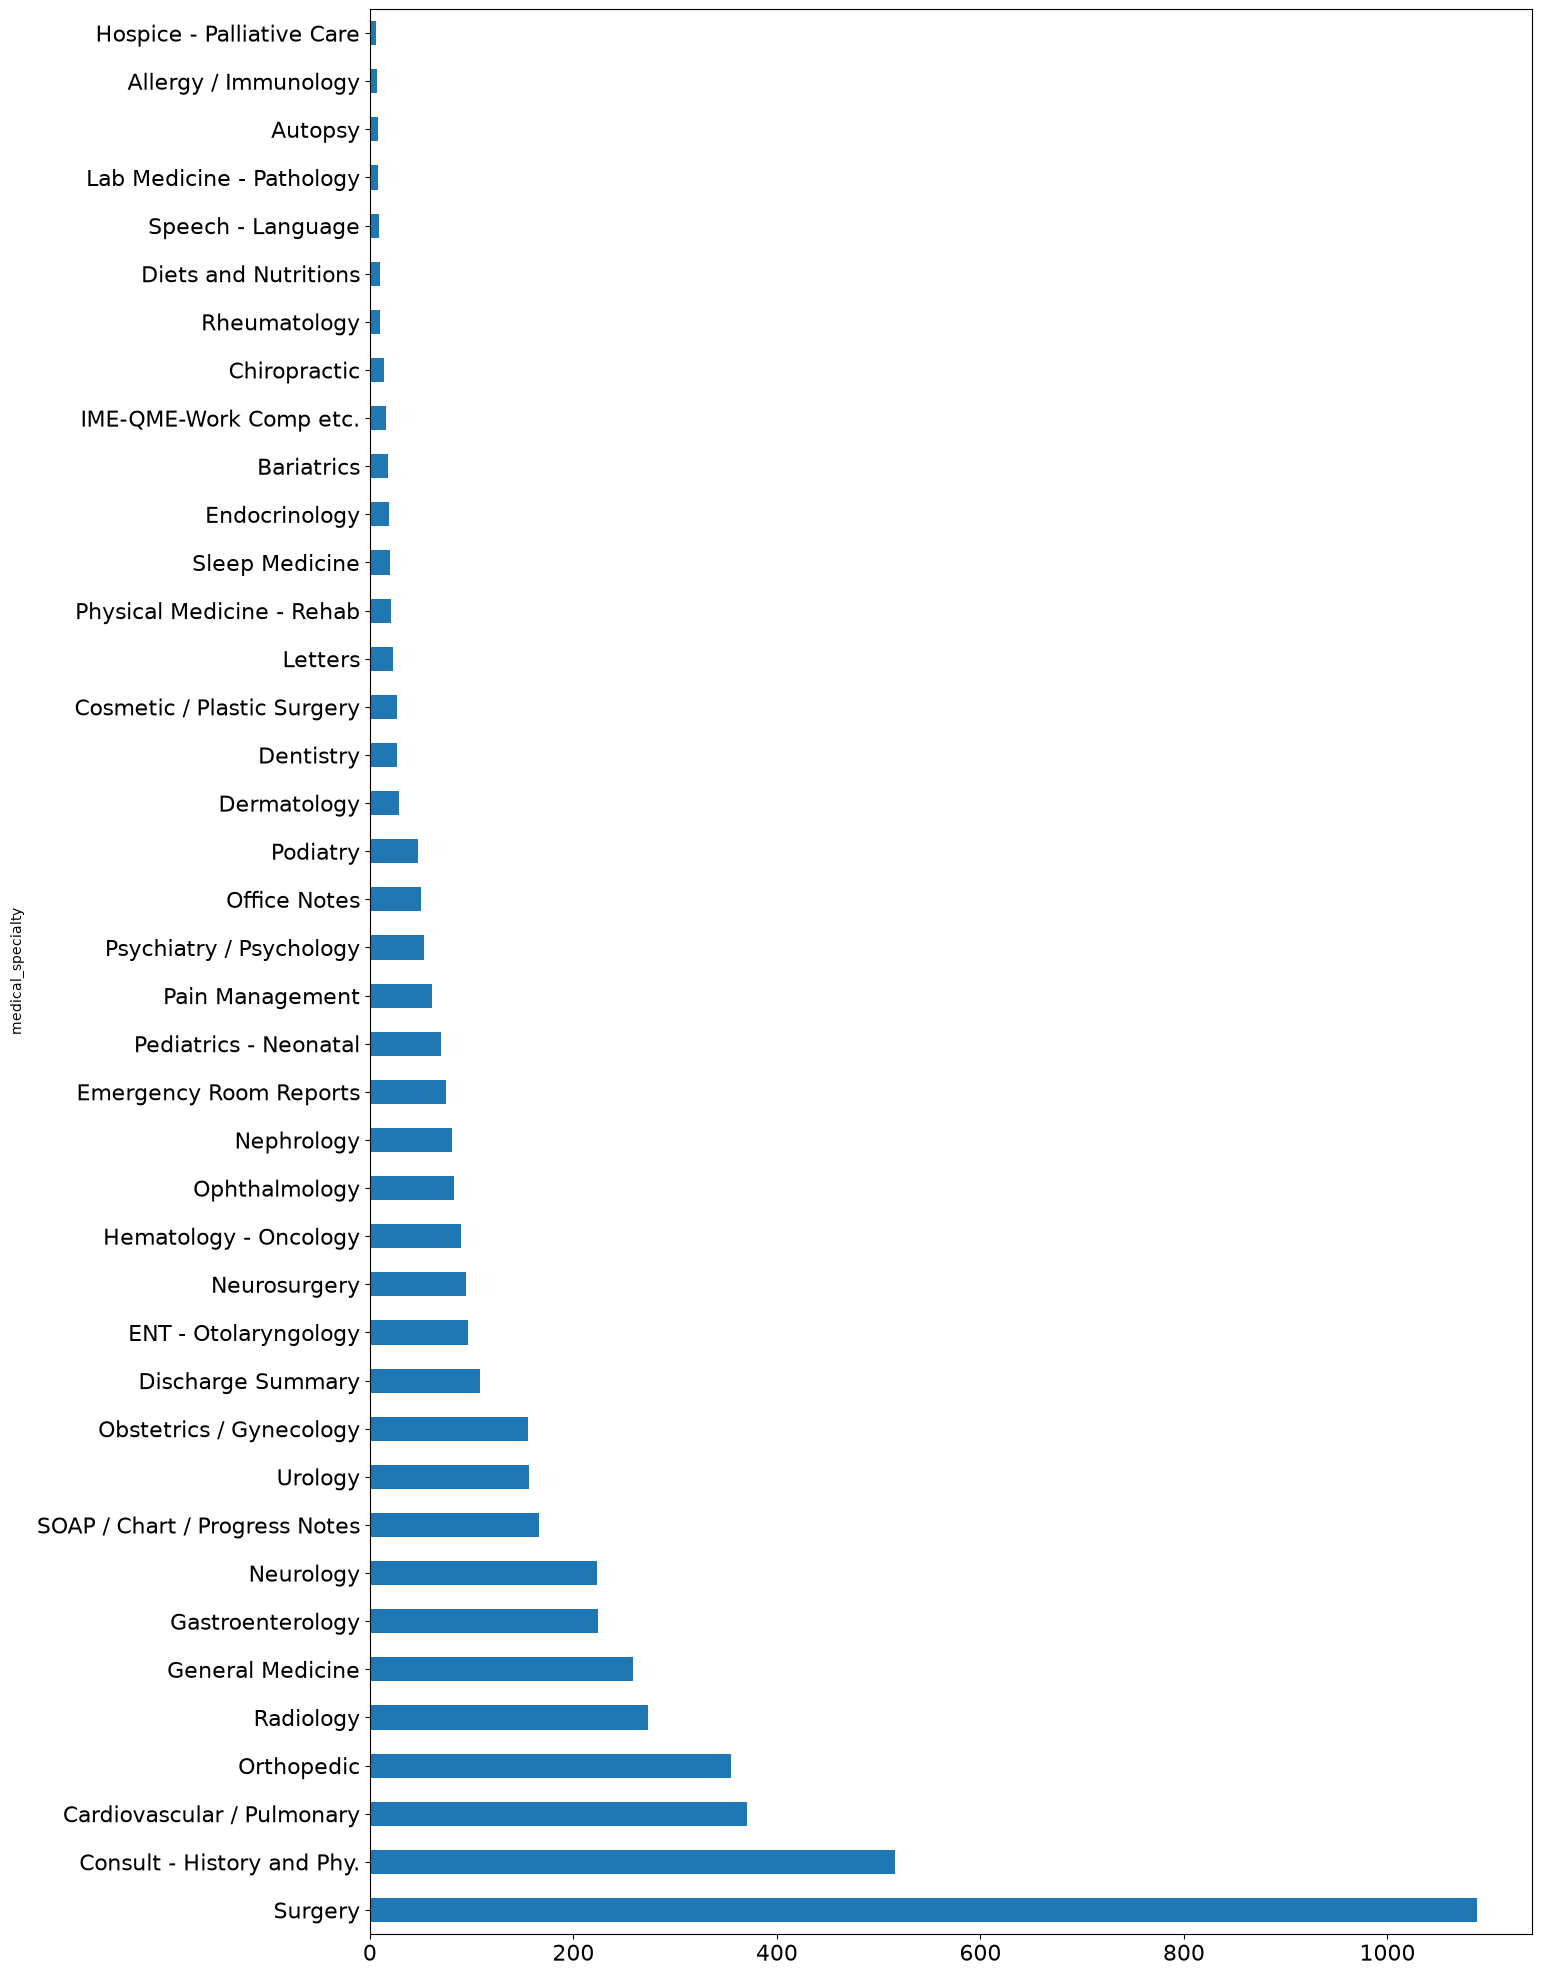

In [15]:
mtsamples['medical_specialty'].value_counts()[:40].plot(kind='barh', figsize=(15,25), fontsize=16)

In [16]:
mtsamples['medical_specialty'].value_counts()
mtsamples[mtsamples['medical_specialty_clean'] == 'Surgery']['transcription'].iloc[0]

'PREOPERATIVE DIAGNOSES:,1.  Hallux rigidus, left foot.,2.  Elevated first metatarsal, left foot.,POSTOPERATIVE DIAGNOSES:,1.  Hallux rigidus, left foot.,2.  Elevated first metatarsal, left foot.,PROCEDURE PERFORMED:,1.  Austin/Youngswick bunionectomy with Biopro implant.,2.  Screw fixation, left foot.,HISTORY: , This 51-year-old male presents to ABCD General Hospital with the above chief complaint.  The patient states that he has had degenerative joint disease in his left first MPJ for many years that has been progressively getting worse and more painful over time.  The patient desires surgical treatment.,PROCEDURE IN DETAIL: , An IV was instituted by the Department of Anesthesia in the preoperative holding area.  The patient was transported from the operating room and placed on the operating room table in the supine position with the safety belt across his lap.  Copious amount of Webril was placed around the left ankle followed by a blood pressure cuff.  After adequate sedation by th

Due to the high number of classes and the subsequent class imbalance, we made two decisions on how to address this:

1. We decided to keep the medical specialities (Excluding the notes/discharges e.t.c) with more than 100 observations. We did this because we know that this amounts to about 75% of the entire data - Justification is that these specialities cover the biggest proportion of the data/demand

2. We decided to carry out dimentionality reduction of the classes by grouping the classes to 5 major classes and then using those new classes as our targets.

## Pathway 1.

- Keeping the bigger classes with >= 100 observations

In [17]:
top_mtsamples = mtsamples[mtsamples['medical_specialty'].isin(top_specialities.index)]

Next we remove the notes/report specialties

In [18]:
top_mtsamples['medical_specialty'].value_counts()

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
Name: count, dtype: int64

In [19]:
top_mtsamples = top_mtsamples[~top_mtsamples['medical_specialty_clean'].isin(['SOAP / Chart / Progress Notes', 'Discharge Summary', 'Consult - History and Phy.'])]

In [20]:
top_mtsamples.shape

(3104, 6)

We then need to create presentable plots for the pathways.

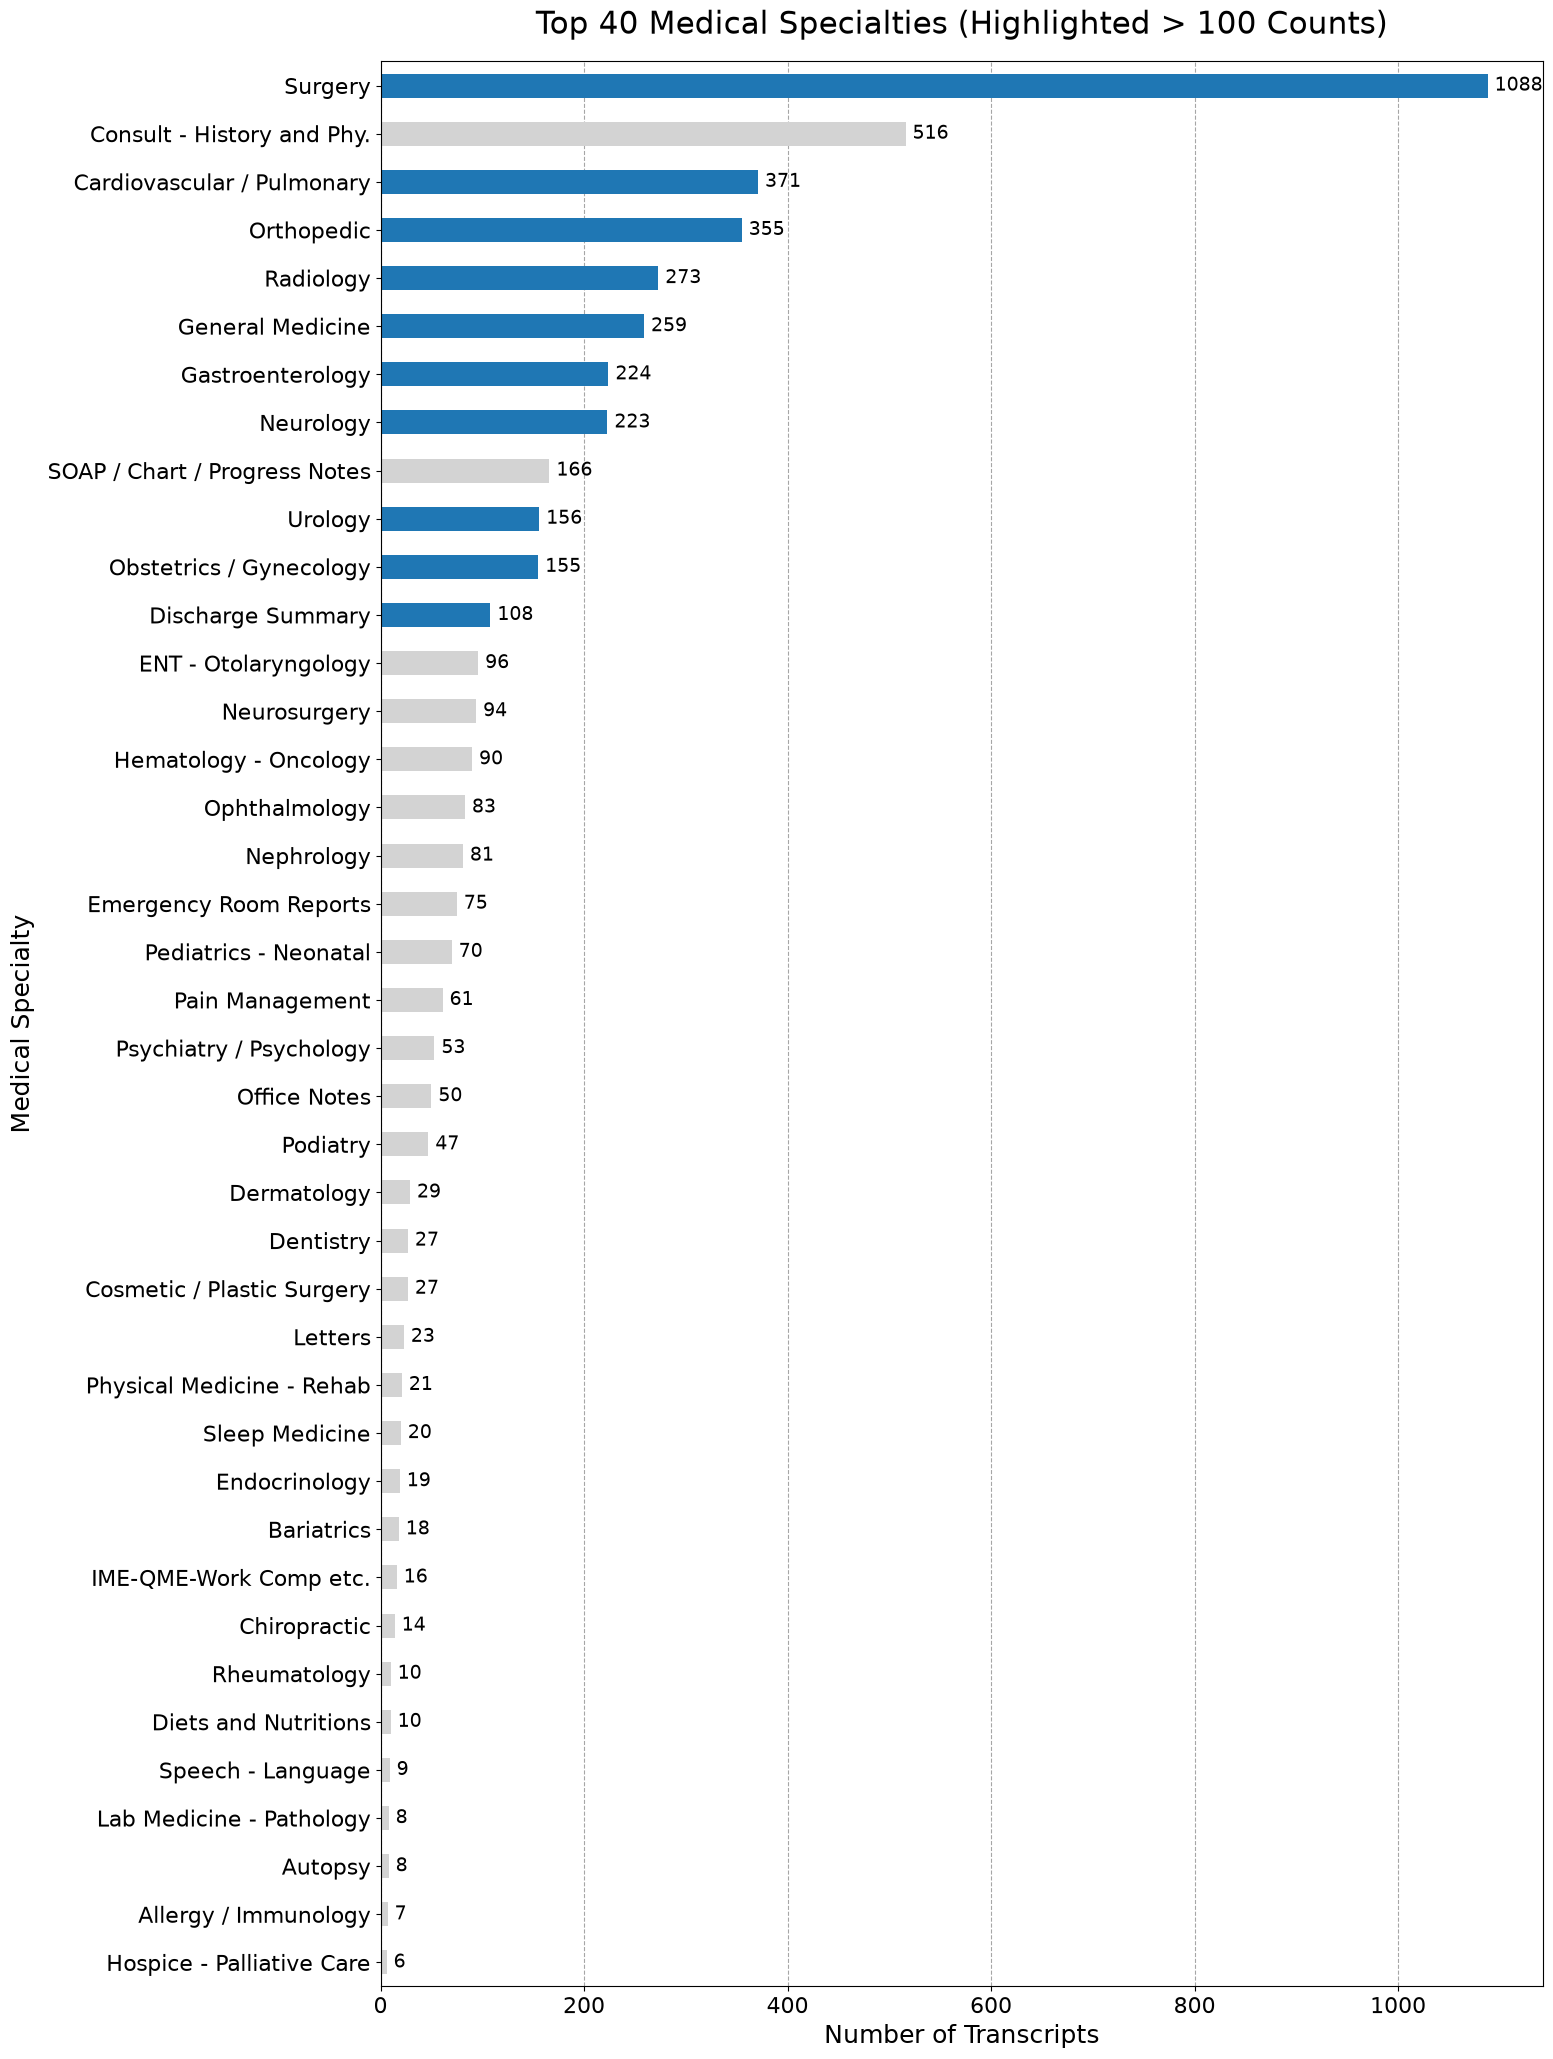

In [8]:
# 1. Isolate the top 40 specialties
top_40 = mtsamples['medical_specialty'].value_counts()[:40]

# 2. Define the non-clinical structural notes to exclude from the blue highlighting
excluded_notes = [
    'Consult - History and Phy.', 
    'SOAP / Chart / Progress Notes'
]

# 3. Create a dynamic color list for the first plot
# It iterates through your series and assigns blue only if count > 100 AND it is not excluded
colors = []
for specialty, count in top_40.items():
    # .strip() is used just in case there is trailing whitespace in the index
    if count > 100 and specialty.strip() not in excluded_notes:
        colors.append('#1f77b4')  # Matplotlib's standard blue
    else:
        colors.append('lightgray')

# ==========================================
# PLOT 1: All 40 Bars with Highlighted Colors
# ==========================================
fig1, ax1 = plt.subplots(figsize=(15, 25))

# Pass the custom color list directly to the plot
top_40.plot(kind='barh', color=colors, ax=ax1, fontsize=16)

# Add vertical grid lines behind the bars
ax1.grid(axis='x', linestyle='--', alpha=0.7, color='gray')
ax1.set_axisbelow(True) # Ensures the grid stays behind the bars

# Add the counts beside the bars
for container in ax1.containers:
    ax1.bar_label(container, padding=5, fontsize=14, color='black')

# Add titles and labels for clarity
plt.title("Top 40 Medical Specialties (Highlighted > 100 Counts)", fontsize=22, pad=20)
plt.xlabel("Number of Transcripts", fontsize=18)
plt.ylabel("Medical Specialty", fontsize=18)

# Display the first plot
ax1.invert_yaxis()
plt.show()



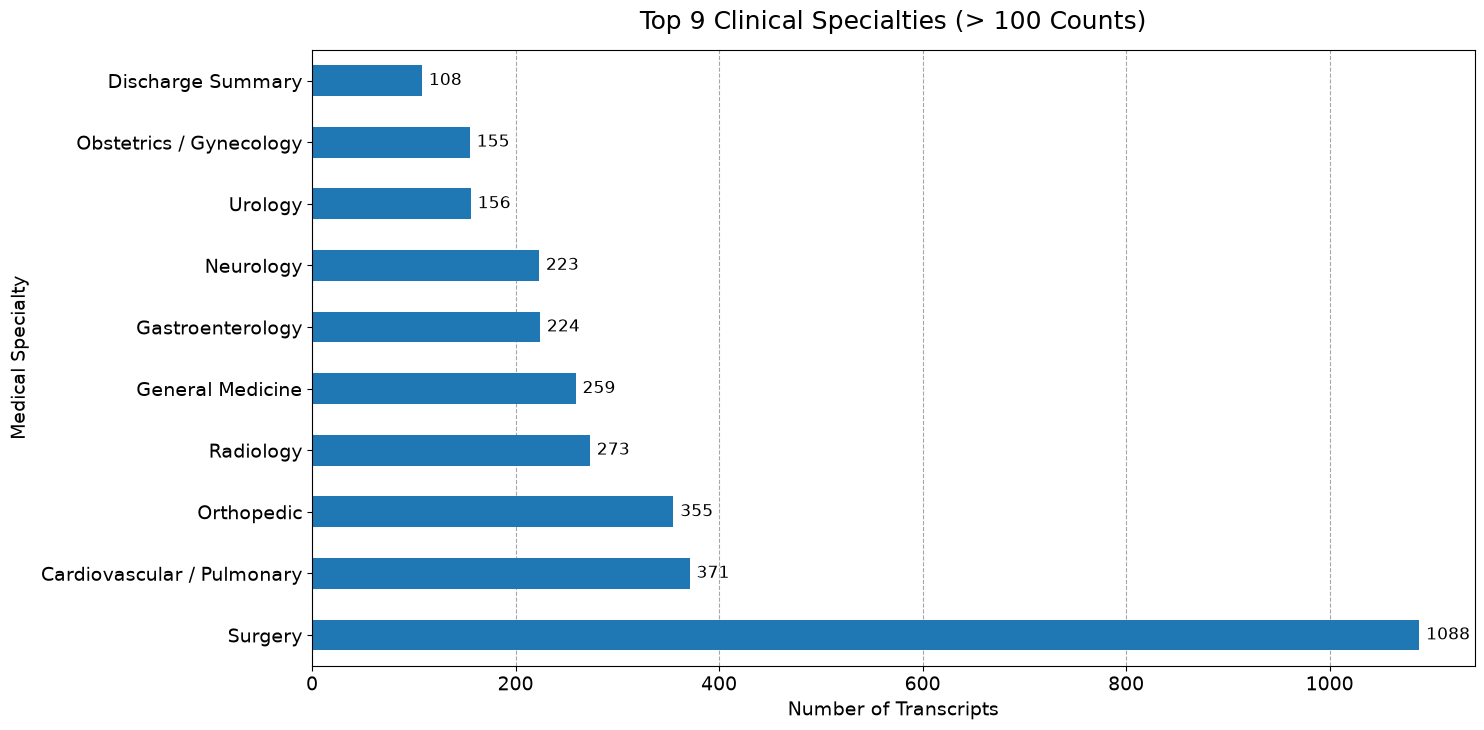

In [12]:
# ==========================================
# PLOT 2: Only the 9 Highlighted Specialties
# ==========================================
# Filter the original series to only include the 9 target specialties
target_specialties = top_40[(top_40 > 100) & (~top_40.index.str.strip().isin(excluded_notes))]

fig2, ax2 = plt.subplots(figsize=(15, 8))

# Plot only these 9 specialties (they will all be blue by default)
target_specialties.plot(kind='barh', color='#1f77b4', ax=ax2, fontsize=14)

# Add the vertical grid lines here as well
ax2.grid(axis='x', linestyle='--', alpha=0.7, color='gray')
ax2.set_axisbelow(True)

# Add the counts beside the bars
for container in ax2.containers:
    ax2.bar_label(container, padding=5, fontsize=12, color='black')

# Add titles and labels
plt.title("Top 9 Clinical Specialties (> 100 Counts)", fontsize=18, pad=15)
plt.xlabel("Number of Transcripts", fontsize=14)
plt.ylabel("Medical Specialty", fontsize=14)

# Display the second plot
ax1.invert_yaxis()
plt.show()

We have remained with about 62% of the data that we started with.

- Next we need write the data to a csv in the data column

In [21]:
top_mtsamples.to_csv("../data/top_mtsamples.csv", index=False)

## Pathway 2.

- Carry out dimensionality reduction and reduce the medical specialities to a smaller number.

Due to the high number of specialitities we need to reduce the specialities to major groups. We will use the groupings as provided by [ultimate list of medical specialties](https://www.sgu.edu/blog/medical/ultimate-list-of-medical-specialties/) as a guide to reduce the number of classes.

We will drop the structural document speciality types and only remain with clinical super classes. The clinical super classes will be grouped as below:
- **surgical_and_procedural**
    - Surgery
    - Neurosurgery
    - Orthopedic
    - Cosmetic / Plastic Surgery
    - ENT - Otolaryngology
    - Bariatrics
    - Urology
    - Obstetrics / Gynecology
- **internal_and_systemic_medicine**
    - General Medicine
    - Cardiovascular / Pulmonary
    - Gastroenterology
    - Hematology - Oncology
    - Nephrology
    - Endocrinology
    - Rheumatology
    - Allergy / Immunology
    - Pediatrics - Neonatal
    - Sleep Medicine
    - Dermatology
    - Hospice - Palliative Care
- **neurology_and_behavioural**
    - Neurology
    - Psychiatry / Psychology
- **diagnostic_and_pathology**
    - Radiology
    - Lab Medicine - Pathology
    - Autopsy
- **rehab_and_applied_health**
    - Physical Medicine - Rehab
    - Pain Management
    - Podiatry
    - Chiropractic
    - Dentistry
    - Diets and Nutritions
    - Speech - Language

In [14]:
# Define the context irrelevant specialities
irrelevant_labels = [
    'Consult - History and Phy.',
    'SOAP / Chart / Progress Notes',
    'Discharge Summary',
    'Emergency Room Reports',
    'Letters',
    'Office Notes',
    'IME-QME-Work Comp etc.'
]

# Define the super_classes
superclass_mapping = {
    # surgical_and_procedural
    'Surgery': 'surgical_and_procedural',
    'Neurosurgery': 'surgical_and_procedural',
    'Orthopedic': 'surgical_and_procedural',
    'Cosmetic / Plastic Surgery': 'surgical_and_procedural',
    'ENT - Otolaryngology': 'surgical_and_procedural',
    'Bariatrics': 'surgical_and_procedural',
    'Urology': 'surgical_and_procedural',
    'Obstetrics / Gynecology': 'surgical_and_procedural',
    'Ophthalmology': 'surgical_and_procedural',
    
    # internal_and_systemic_medicine
    'General Medicine': 'internal_and_systemic_medicine',
    'Cardiovascular / Pulmonary': 'internal_and_systemic_medicine',
    'Gastroenterology': 'internal_and_systemic_medicine',
    'Hematology - Oncology': 'internal_and_systemic_medicine',
    'Nephrology': 'internal_and_systemic_medicine',
    'Endocrinology': 'internal_and_systemic_medicine',
    'Rheumatology': 'internal_and_systemic_medicine',
    'Allergy / Immunology': 'internal_and_systemic_medicine',
    'Pediatrics - Neonatal': 'internal_and_systemic_medicine',
    'Sleep Medicine': 'internal_and_systemic_medicine',
    'Dermatology': 'internal_and_systemic_medicine',
    'Hospice - Palliative Care': 'internal_and_systemic_medicine',
    
    # neurology_and_behavioural
    'Neurology': 'neurology_and_behavioural',
    'Psychiatry / Psychology': 'neurology_and_behavioural',
    
    # diagnostic_and_pathology
    'Radiology': 'diagnostic_and_pathology',
    'Lab Medicine - Pathology': 'diagnostic_and_pathology',
    'Autopsy': 'diagnostic_and_pathology',
    
    # rehab_and_applied_health
    'Physical Medicine - Rehab': 'rehab_and_applied_health',
    'Pain Management': 'rehab_and_applied_health',
    'Podiatry': 'rehab_and_applied_health',
    'Chiropractic': 'rehab_and_applied_health',
    'Dentistry': 'rehab_and_applied_health',
    'Diets and Nutritions': 'rehab_and_applied_health',
    'Speech - Language': 'rehab_and_applied_health'
}

In [15]:
# Filter out the irrelevant structural notes
super_clinical_mtsamples = mtsamples[~mtsamples['medical_specialty_clean'].isin(irrelevant_labels)].copy()

# Create the new target column by mapping the dictionary to the cleaned column
super_clinical_mtsamples['clinical_superclass'] = super_clinical_mtsamples['medical_specialty_clean'].map(superclass_mapping)

In [16]:
# sanity check: verify there are no unmapped (NaN) values in the new column
unmapped_check = super_clinical_mtsamples['clinical_superclass'].isna().sum()
print(f"Unmapped rows: {unmapped_check}")

# View the new class distribution
print(super_clinical_mtsamples['clinical_superclass'].value_counts())

Unmapped rows: 0
clinical_superclass
surgical_and_procedural           2072
internal_and_systemic_medicine    1186
diagnostic_and_pathology           289
neurology_and_behavioural          276
rehab_and_applied_health           189
Name: count, dtype: int64


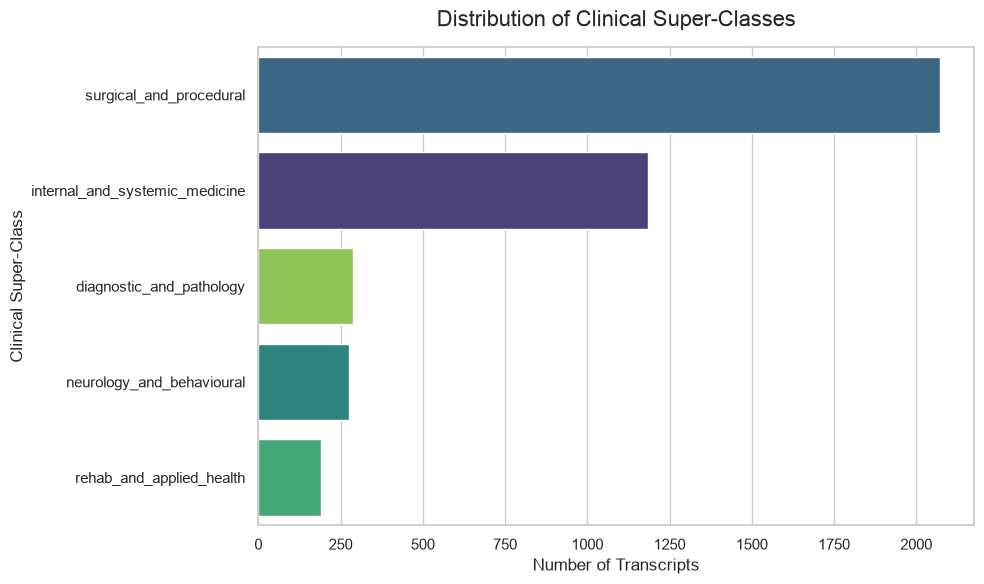

In [17]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
plt.figure(figsize=(10, 6))

# Create a horizontal count plot, ordered from largest to smallest class
ax = sns.countplot(
    data=super_clinical_mtsamples,
    y='clinical_superclass',
    hue='clinical_superclass',
    order=super_clinical_mtsamples['clinical_superclass'].value_counts().index,
    palette='viridis',
    legend=False
)

# Add clear labels and a title
ax.set_title('Distribution of Clinical Super-Classes', fontsize=16, pad=15)
ax.set_xlabel('Number of Transcripts', fontsize=12)
ax.set_ylabel('Clinical Super-Class', fontsize=12)

# Ensure everything fits without being cut off
plt.tight_layout()

# Display the plot
plt.show()

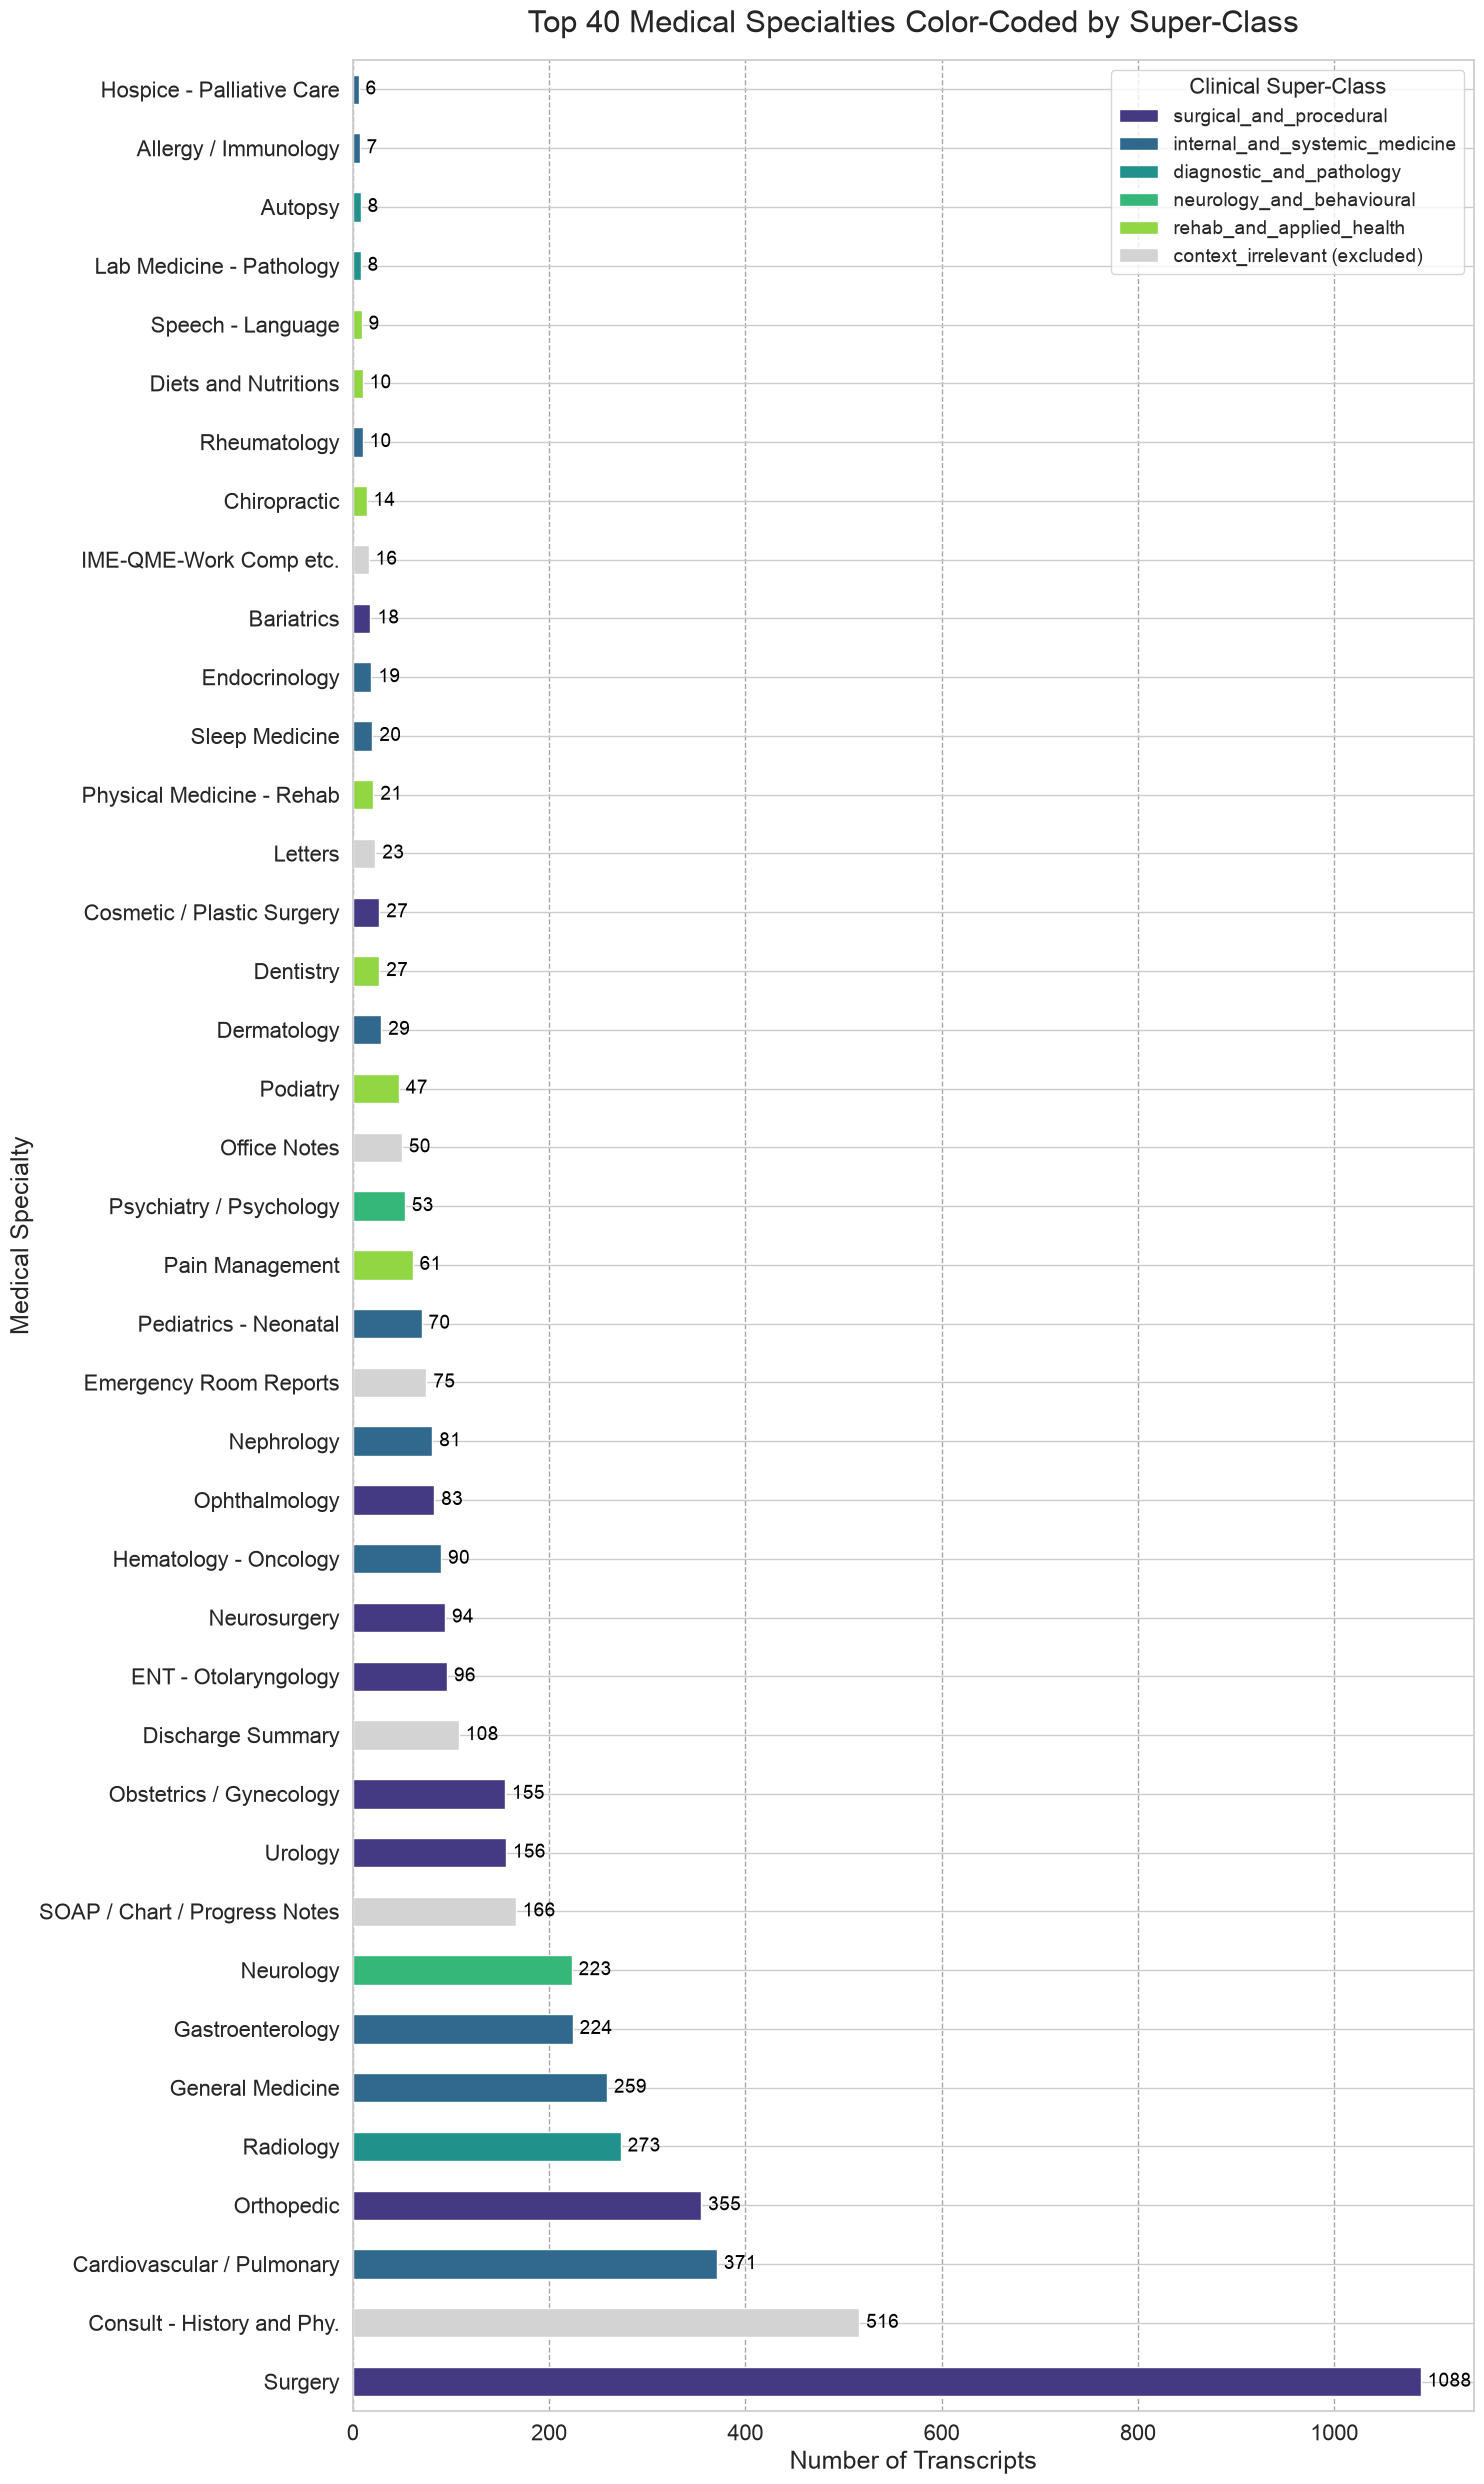

In [21]:
from matplotlib.patches import Patch

# ==========================================
# 1. COLOR MAP GENERATION
# ==========================================

# 1. Get the top 40 original specialties
top_40 = mtsamples['medical_specialty_clean'].value_counts()[:40]

# 2. Get the super-classes ordered by frequency (matches the Seaborn plot order)
ordered_superclasses = (
    super_clinical_mtsamples['clinical_superclass']
    .value_counts()
    .index.tolist()
)

# 3. Extract the exact viridis palette used in your Seaborn countplot
viridis_palette = sns.color_palette('viridis', len(ordered_superclasses))
superclass_color_map = dict(zip(ordered_superclasses, viridis_palette))

# 4. Construct a color list for the 40 specialties
bar_colors = []
for specialty in top_40.index:
    specialty_clean = specialty.strip()
    if specialty_clean in irrelevant_labels:
        bar_colors.append('lightgray')
    elif specialty_clean in superclass_mapping:
        mapped_class = superclass_mapping[specialty_clean]
        bar_colors.append(superclass_color_map[mapped_class])
    else:
        bar_colors.append('lightgray')


# ==========================================
# 2. PLOTTING THE CHART
# ==========================================

fig, ax = plt.subplots(figsize=(15, 25))

# Plot the horizontal bars with the dynamic colors
top_40.plot(kind='barh', color=bar_colors, ax=ax, fontsize=16)

# Add gridlines behind the bars
ax.grid(axis='x', linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

# Add count annotations next to each bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=14, color='black')

# Create a custom legend matching the super-classes + excluded label
legend_handles = [
    Patch(facecolor=color, label=sc_name)
    for sc_name, color in superclass_color_map.items()
]
legend_handles.append(Patch(facecolor='lightgray', label='context_irrelevant (excluded)'))

ax.legend(
    handles=legend_handles,
    title="Clinical Super-Class",
    fontsize=14,
    title_fontsize=16,
    loc='upper right',
    frameon=True
)

# Formatting titles and axis labels
plt.title("Top 40 Medical Specialties Color-Coded by Super-Class", fontsize=22, pad=20)
plt.xlabel("Number of Transcripts", fontsize=18)
plt.ylabel("Medical Specialty", fontsize=18)

plt.tight_layout()
plt.show()

In [19]:
super_clinical_mtsamples.to_csv("../data/super_clinical_mtsamples.csv", index=False)